# Assignment 2: FOMC Communication and Asset Prices

**Victor Chen (yc8027)**<br>
FRE-GY 7871 A - Fall 2026<br>
Information cutoff: **September 13, 2026**

This notebook compares Powell- and Warsh-era Federal Reserve communication and
relates three text measures to daily asset-price changes.

## Reproduction

To reproduce the saved fallback result, first run `python -m src.train_temporal_roberta`,
set `FOMC_MODEL_PATH=data/models/fomc-roberta-temporal`, then run
`python scripts/run_v2.py --refresh-documents --refresh-market --rescore`.
Raw and derived data are written only to Git-ignored directories. The outputs
below are embedded so this notebook remains viewable on GitHub.

In [1]:
import json, pandas as pd
from pathlib import Path
ROOT=Path.cwd()
scores=pd.read_csv(ROOT/'data/interim/document_scores.csv')
events=pd.read_csv(ROOT/'data/interim/event_reactions_v2.csv')
table3=pd.read_csv(ROOT/'outputs/table3_regressions_v2.csv')
forecast=json.loads((ROOT/'outputs/forecast_v2.json').read_text())
print(f'Documents: {len(scores)}; range: {scores.release_date.min()} to {scores.release_date.max()}')

Documents: 310; range: 2018-02-13 to 2026-08-28


## Methods

1. The exact published ACL 2023 monetary-policy rule, including its documented
   substring matching, conflict precedence, and negation behavior.
2. A RoBERTa-large temporal reproduction trained on the authors' public 1996-2019
   labels, with labels 0=dovish, 1=hawkish, 2=neutral. Its untouched 2020-2022
   test weighted F1 is 0.753 (N=466). The gated official checkpoint remained
   pending and is not claimed here.
3. `ProsusAI/finbert`, measured as mean `P(positive)-P(negative)`. This is
   financial sentiment and is not renamed hawkishness.

All use the same policy-topic sentences. Press-conference reporter questions and
minutes staff forecasts are excluded. See `METHODOLOGY.md` for the audit trail.

## Table 1. Documents collected by type and Chair

In [2]:
pd.read_csv(ROOT/'outputs/table1_document_counts_v2.csv')

,doc_type,subtype,Powell,Warsh,Total
0,Chair communication,press_conference,64,2,66
1,Chair communication,speech,78,1,79
2,Chair communication,testimony,26,1,27
3,Minutes,minutes,67,2,69
4,Statement,statement,67,2,69


## Tone levels and Figure 1

In [3]:
scores.groupby(['chair','doc_type'])[['wordlist_score','roberta_score','finbert_sentiment']].agg(['mean','count'])

wordlist_score       roberta_score       finbert_sentiment      
                                     mean count          mean count              mean count
chair  doc_type                                                                            
Powell Chair communication         -0.209   160         0.104   160             0.036   160
       Minutes                     -0.195    67         0.115    67             0.026    67
       Statement                    0.002    67         0.199    67             0.145    67
Warsh  Chair communication         -0.069     4         0.272     4             0.130     4
       Minutes                     -0.012     2         0.514     2             0.148     2
       Statement                    0.200     2         0.600     2             0.574     2

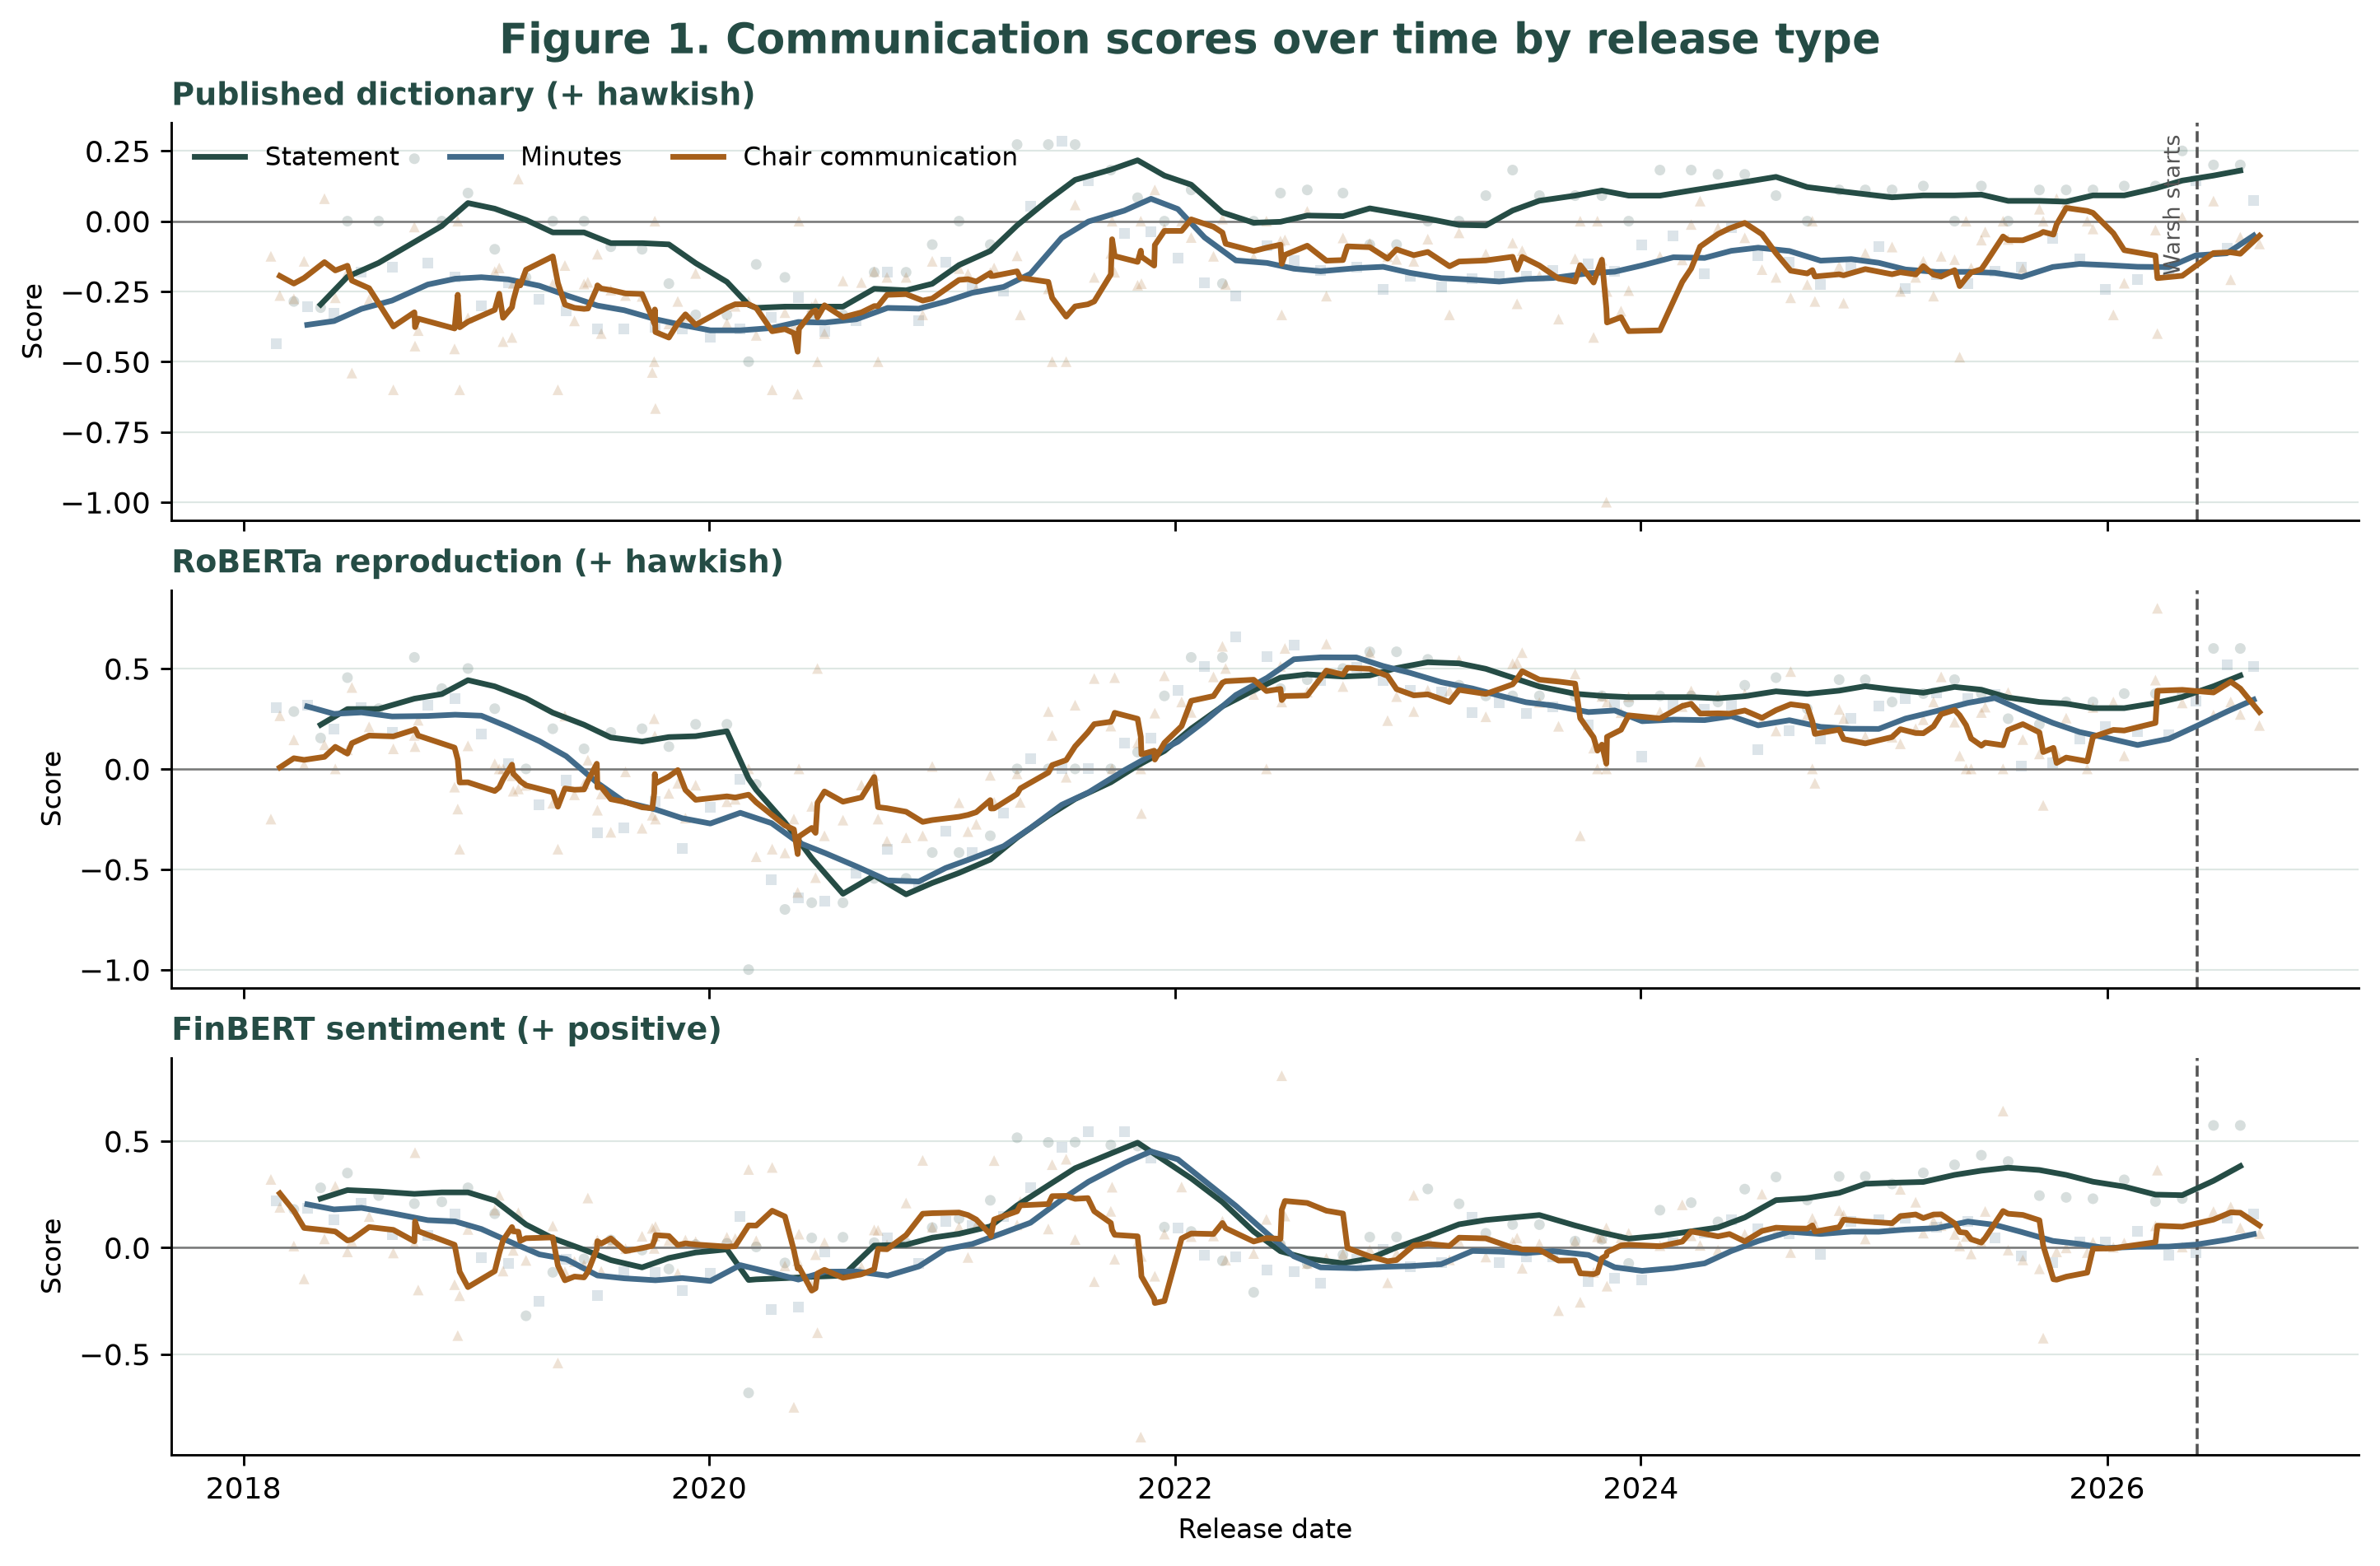

In [4]:
from IPython.display import Image,display
display(Image('outputs/figure1_tone_trends_v2.png'))

The first two panels measure hawkishness; FinBERT measures positive versus
negative financial language. The Warsh averages are descriptive because only
eight Warsh-era documents are available.

## Table 2. Warsh-era releases and one-day changes

In [5]:
table2_columns=['release_date','subtype','wordlist_score','roberta_score',
 'finbert_sentiment','dxy_change_pct','spread_change_bp','dgs1_change_bp','growth_value_pp']
events.loc[events.chair.eq('Warsh'), table2_columns]

,Date,Release,Dictionary,RoBERTa repro.,FinBERT sentiment,DXY %,10s2s bp,1Y bp,G-V pp
302,2026-06-17,press_conference,0.071,0.268,0.169,0.553,-9.0,14.0,-0.258
303,2026-06-17,statement,0.200,0.600,0.574,0.553,-9.0,14.0,-0.258
304,2026-07-08,minutes,-0.096,0.519,0.138,-0.089,-1.0,0.0,1.506
305,2026-07-14,testimony,-0.208,0.333,0.191,-0.336,4.0,-10.0,1.431
306,2026-07-29,press_conference,-0.057,0.271,0.093,-0.572,10.0,-5.0,-0.966
307,2026-07-29,statement,0.200,0.600,0.574,-0.572,10.0,-5.0,-0.966
308,2026-08-19,minutes,0.073,0.509,0.158,-0.823,-6.0,1.0,-0.842
309,2026-08-28,speech,-0.081,0.216,0.066,0.545,-8.0,11.0,-0.208


Statements and press conferences on June 17 and July 29 share daily market
windows. They remain separate document rows for Table 2, but date-clustered
standard errors prevent treating their duplicated returns as independent.

## Table 3. Pooled daily regressions

In [6]:
table3.query("`Document type` == 'Pooled'")

,Indicator,Tone method,Tone coefficient,Tone SE,Tone p-value,DGS3MO coefficient,Adjusted R2,N
36,DXY (%),Published dictionary,0.0275,0.0252,0.2760,0.0405,0.0898,293
37,DXY (%),RoBERTa reproduction,0.0115,0.0296,0.6973,0.0407,0.0874,293
38,DXY (%),FinBERT sentiment,0.0439,0.0265,0.0992,0.0397,0.0960,293
39,10s2s (bp),Published dictionary,0.1000,0.3100,0.7474,-0.4424,0.0885,295
40,10s2s (bp),RoBERTa reproduction,-0.1381,0.2775,0.6193,-0.4399,0.0891,295
41,10s2s (bp),FinBERT sentiment,-0.1255,0.2264,0.5798,-0.4378,0.0888,295
42,1Y yield (bp),Published dictionary,0.0805,0.2242,0.7200,1.0134,0.3693,295
43,1Y yield (bp),RoBERTa reproduction,0.1221,0.2727,0.6547,1.0131,0.3697,295
44,1Y yield (bp),FinBERT sentiment,0.1836,0.1924,0.3410,1.0093,0.3703,295
45,Growth - value (pp),Published dictionary,-0.0435,0.1002,0.6648,0.0022,-0.0066,294


Each row is a separate regression of the indicator change on a one-standard-
deviation text score and the matching-window DGS3MO change. Pooled regressions add
document-type fixed effects and a Warsh indicator; uncertainty is clustered by
event end date. Coefficients estimate daily conditional association, not a
high-frequency causal wording shock. At the pooled level, only FinBERT-DXY reaches
10% significance. Type-specific clues are stronger: more-hawkish minutes are
associated with a flatter 10s2s curve, while more-positive statements are
associated with higher 1-year yields.

## Type-specific and 2020-exclusion checks

In [7]:
table3.query("`Document type` != 'Pooled'")

,Document type,Indicator,Tone method,Tone coefficient,Tone p-value,Tone coefficient excluding 2020,N
0,Statement,DXY (%),Published dictionary,0.0854,0.0705,0.0964,69
1,Statement,DXY (%),RoBERTa reproduction,0.0262,0.6399,-0.0354,69
2,Statement,DXY (%),FinBERT sentiment,0.1085,0.0879,0.1334,69
3,Statement,10s2s (bp),Published dictionary,0.4936,0.2751,0.3177,69
4,Statement,10s2s (bp),RoBERTa reproduction,-0.1751,0.7085,-1.4825,69
5,Statement,10s2s (bp),FinBERT sentiment,0.3951,0.5042,0.2663,69
6,Statement,1Y yield (bp),Published dictionary,-0.0455,0.9225,-0.1571,69
7,Statement,1Y yield (bp),RoBERTa reproduction,0.3065,0.4764,1.1385,69
8,Statement,1Y yield (bp),FinBERT sentiment,1.1411,0.0409,1.3951,69
9,Statement,Growth - value (pp),Published dictionary,-0.0438,0.8213,-0.0658,69


## September 15-16, 2026 forecast

In [8]:
pd.DataFrame.from_dict(forecast['rate_probabilities'],orient='index',columns=['Probability (%)'])

,Probability (%)
Cut,6
Hold,73
Hike,21


These probabilities come from an L2-regularized multinomial model using only
the previous decision and the dictionary/RoBERTa scores of the previous statement,
latest minutes, and intermeeting Chair communications. No CME or other market
probability is used.

In [9]:
pd.DataFrame([{'Model':'Previous decision only',**forecast['premeeting_model']['baseline_backtest']},{'Model':'Previous decision + pre-meeting tone',**forecast['premeeting_model']['backtest']}]).set_index('Model')

,n,accuracy,log_loss,brier
Model,,,,
Previous decision only,48,0.625,0.795,0.458
Previous decision + pre-meeting tone,48,0.729,0.711,0.408


Statement versus July 29: **44% more hawkish** and **56% not more hawkish**. The second category includes a less-hawkish or unchanged statement; this is a relative-change forecast, not an absolute hawkish/dovish label. The probabilities weight historical tone-change rates after each decision by the internally predicted decision probabilities.

In [10]:
pd.DataFrame(forecast['market_reaction']).T

,probability_rise,expected_change,unit,prediction_sd,prediction_interval_80
DXY (%),53,0.039659,%,0.46028,"[-0.5502132561137197, 0.629530972574715]"
10s2s (bp),44,-0.62973,bp,4.433532,"[-6.3115300503716085, 5.052070458233793]"
1Y yield (bp),55,0.579751,bp,5.007574,"[-5.83771345112307, 6.997214456949397]"
Growth - value (pp),56,0.194423,pp,1.236795,"[-1.3905937658422545, 1.7794405549749488]"


The market estimates set DGS3MO to zero, so they represent the conditional
language-associated component rather than a separate rate-surprise forecast.
All four direction probabilities remain close to 50%, and the expected changes
are small relative to residual uncertainty. These are low-confidence academic
model outputs; no investment recommendation is made.

## Comparison with the required readings

**How You Say It Matters (2021).** That study separates qualitative wording from
the rate action and uses intraday prices. This analysis pursues the same separation
with DGS3MO, but its daily window is noisier and cannot identify a pure surprise.

**Deciphering Federal Reserve Communication (2023 revision).** That paper defines
tone relative to unavailable contemporaneous staff alternatives and distinguishes
tone, novelty, and expectation. Here, the public dictionary and RoBERTa reproduction
are reproducible in real time; no score is presented as a market surprise.

**Parsing the Fed (2021).** The presentation finds that word-list, similarity, and
FinBERT results depend on the indicator. The present results likewise compare all
methods and assets. FinBERT's financial valence is kept distinct from policy
stance, avoiding a positive=dovish or negative=hawkish relabeling.

## Verification

Targeted tests cover the published rule, negation, conflict precedence, reporter
exclusion, minutes sections, equity versus Treasury closing times, missing
controls, and exact-close roll-forward.

In [11]:
!python -m pytest tests -q

12 passed
